In [1]:
# Esame 654AA - a.a. 2025/2026
# Studenti: Leonardo Celati, Samuele Taviano
# Matricole: 660185, ?

In [2]:
import importlib
from sklearn.svm import SVC
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, cross_val_predict
import wine_common as wine
import svm_common as sc

importlib.reload(wine)

<module 'wine_common' from '/Users/leonardo/workspace/library/source/it.unipi.654AA/monk/wine_common.py'>

In [3]:
# Note: The regularization parameter C is explored on a logarithmic scale over four orders of magnitude,
# from strong (0.1) to weak regularization (100), following standard practice for SVM hyperparameter tuning.
param_grid_default = [
    {  # linear
        "svm__kernel": ["linear"],
        "svm__C": [0.1, 1, 10, 100],
    },
    {  # poly
        "svm__kernel": ["poly"],
        "svm__C": [0.1, 1, 10, 100],
        "svm__gamma": ["scale", 0.1, 1],
        "svm__degree": [2, 3, 4],
    },
    {  # sigmoid
        "svm__kernel": ["sigmoid"],
        "svm__C": [0.1, 1, 10, 100],
        "svm__gamma": ["scale", 0.1, 1]
    },
    {  # rbf
        "svm__kernel": ["rbf"],
        "svm__C": [0.1, 1, 10, 100],
        "svm__gamma": ["scale", 0.1, 1]
    },
]

# We only test SVC
pipe_default = Pipeline(steps=[
    ("svm", SVC())
])

# CV params
n_split = 5

# Of all parameters 'shuffle' is relevant because the TR set is small
# We also prefer StratifiedKFold as it preserves class balance during folding (optimal in small dataset)
cv_default = StratifiedKFold(n_splits=n_split, shuffle=True, random_state=42)


<h3>Wine dataset</h3>

<h4>Data Loading</h4>
<p>Load and prepare data</p>

In [4]:
df_train, df_test = wine.stratified_split()
X_tr, y_tr, X_ts, y_ts = wine.split_and_prepare_dataset(df_train, df_test)
wine.dataset_introspection(df_train, df_test)

,Property,Training,Test
0,Number of samples,5199,1298
1,Number of features,11,11
2,Class values,"[0, 1]","[0, 1]"
3,Class balance,"class 0 = 3919, class 1 = 1280","class 0 = 979, class 1 = 319"


<h4>Model Selection</h4>
<p>Finding the best model with GridSearchCV.</p>

In [5]:
# Perform a grid search
grid = GridSearchCV(
    estimator = pipe_default,
    param_grid = param_grid_default,
    cv = cv_default,
    scoring = "accuracy",
    n_jobs = -1 # use all available cores
)

# Fit TR features and labels into grid
grid.fit(X_tr, y_tr)
best_model = grid.best_estimator_
sc.grid_introspection(grid)


Total model explored: 64
Best params: {'svm__C': 10, 'svm__degree': 3, 'svm__gamma': 1, 'svm__kernel': 'poly'}
Best CV accuracy: 0.9961534759754201
Best model: Pipeline(steps=[('svm', SVC(C=10, gamma=1, kernel='poly'))])
Total support vectors: 162
Support vectors per class: [82 80]


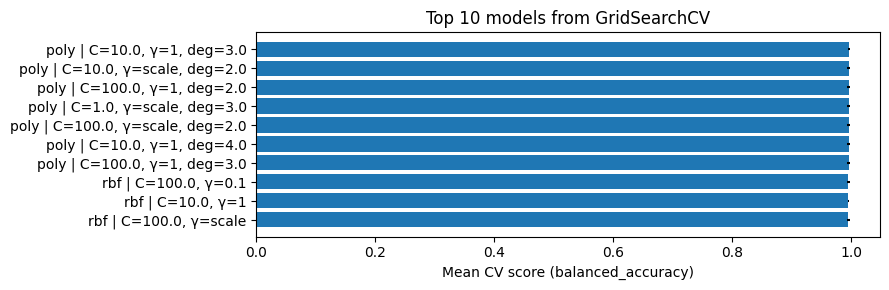

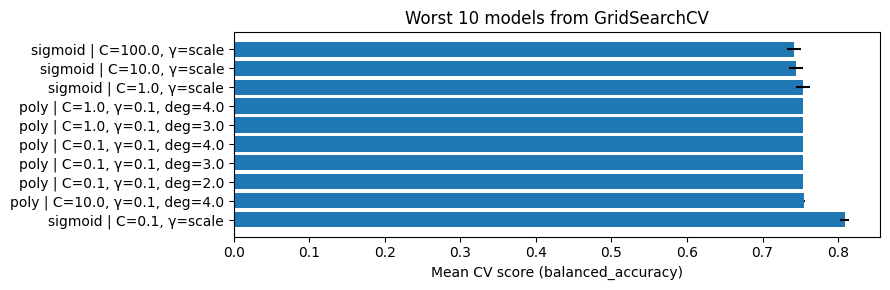

In [6]:
sc.plot_results(grid.cv_results_)

<h4>Model Assesment</h4>
<p>Collecting various metrics for model assesment.</p>

In [7]:
cv_predictions = cross_val_predict(
    best_model,
    X_tr, y_tr,
    cv=cv_default
)

print(classification_report(y_tr, cv_predictions, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3919
           1       0.99      0.99      0.99      1280

    accuracy                           1.00      5199
   macro avg       1.00      0.99      0.99      5199
weighted avg       1.00      1.00      1.00      5199



In [8]:
# Train score
train_score = best_model.score(X_tr, y_tr)

# CV score (stessa CV della GridSearch!)
cv_scores = cross_val_score(
    best_model, X_tr, y_tr,
    cv=cv_default, scoring="balanced_accuracy" # as the classes are unbalanced
)

print(f"Train: {train_score:.3f}")
print(f"CV:    {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
#print(f"Test:  {test_accuracy_1:.3f}")

Train: 0.997
CV:    0.994 ± 0.002


In [9]:
for seed in [0, 1, 2, 3, 4]:
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    scores = cross_val_score(
        best_model,
        X_tr, y_tr,
        cv=cv_default,
        scoring="accuracy"
    )
    print(seed, scores.mean())

0 0.9961534759754201
1 0.9961534759754201
2 0.9961534759754201
3 0.9961534759754201
4 0.9961534759754201


In [21]:
importlib.reload(sc)
sv_freq, perm_imp, comp_attr = sc.compare_svfreq_vs_permutation(
    best_model, X_tr, y_tr, scoring="accuracy"
)

print(comp_attr)

                      SV_freq_max  Perm_importance_sum
density                  0.148887             0.133535
total sulfur dioxide     0.297603             0.100721
volatile acidity         0.238477             0.026630
residual sugar           0.043153             0.023966
alcohol                  0.356906             0.011771
pH                       0.423246             0.005463
sulphates                0.189624             0.003299
free sulfur dioxide      0.149633             0.002674
quality                  0.391975             0.001798
chlorides                0.096469             0.001673
fixed acidity            0.277982             0.001269
citric acid              0.179942             0.000029


<h4>Test predictions</h4>

In [10]:
best_model = grid.best_estimator_

test_predictions = best_model.predict(X_ts)
test_accuracy = best_model.score(X_ts, y_ts)

print(classification_report(y_ts, test_predictions, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      0.22      0.35       979
           1       0.29      1.00      0.45       319

    accuracy                           0.41      1298
   macro avg       0.65      0.61      0.40      1298
weighted avg       0.83      0.41      0.38      1298



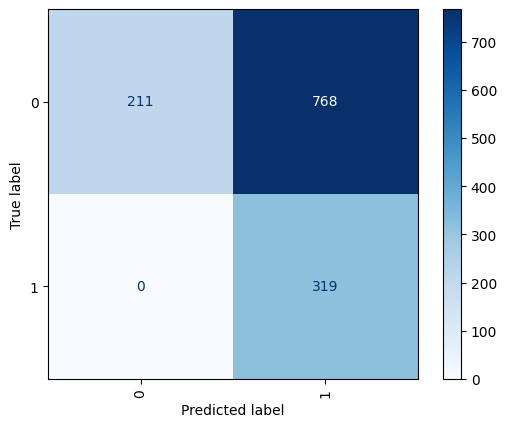

In [11]:
ConfusionMatrixDisplay.from_predictions(y_ts, test_predictions, xticks_rotation='vertical', cmap='Blues');

<h4>Overfitting Introspection</h4>
<p>Applying various techniques to monitor overfitting</p>

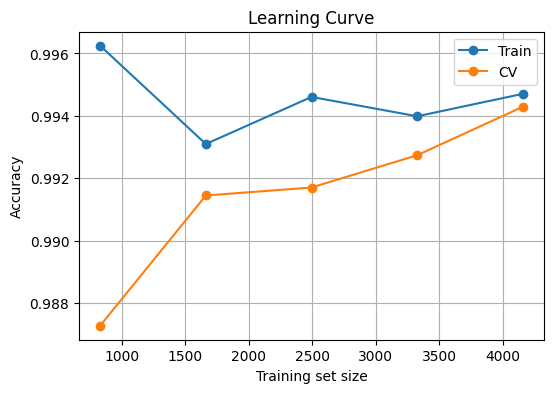

In [12]:
sc.plot_learning_curve_svm(best_model, X_tr, y_tr, cv_default)